In [148]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from idlpy import *
import geopandas as gpd
import cartopy.crs as ccrs
crs = ccrs.Mercator()


In [149]:
# load streamflow data
dfs = []
for s in ['summer','autumn','winter','spring']:
    obs_df = pd.read_csv('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/obs/streamflow/streamflow_obs_'+s+'_gaussian.csv')
    obs_df = obs_df.set_index('date').drop('36001',axis=1)
    
    dfs.append(obs_df)
    
obs_df = pd.concat(dfs)
obs_df = obs_df.sort_index()


# populate start year dictionary
start_year_dict = {}
for site in obs_df:
    start_year_dict[site] = [float(obs_df[site].first_valid_index().split('-')[0])]
    
start_years = pd.DataFrame(start_year_dict)


# catchment
fp = '/nesi/project/niwa00015/queenle/data/arcgis/'
file = 'NESTCAT_v2_NZTM.shp'
catchment_data = gpd.read_file(fp+file)
catchment_data = catchment_data.to_crs("EPSG:4326")

catchment_data = catchment_data.loc[catchment_data['SITE'].isin(obs_df.columns)]
catchment_data.index = catchment_data['SITE']

font = {'family': 'sans-serif',
        'color':  'black',
        'weight': 'normal',
        'size': 22,
        }


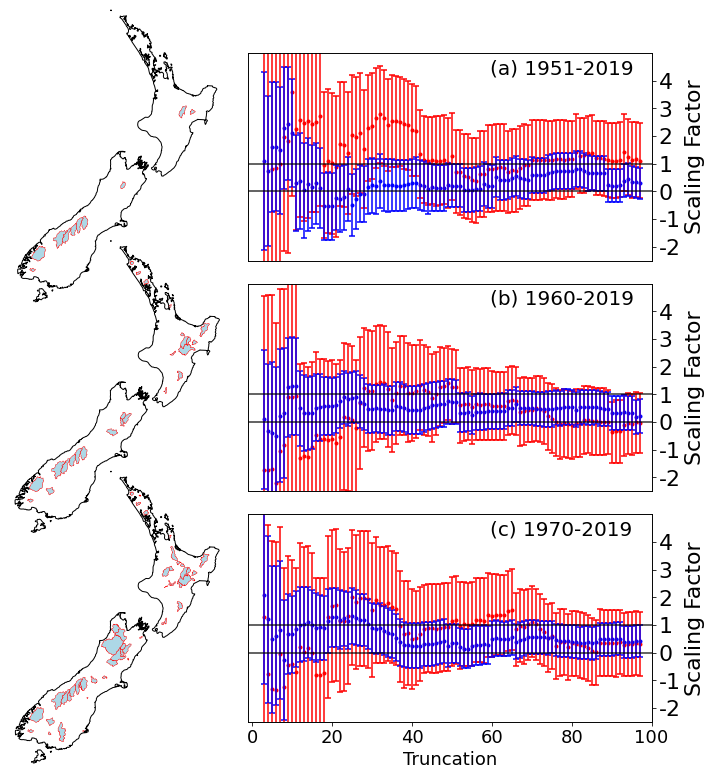

In [162]:
'''
GAUSSIAN RESULTS
'''

# Set-up figure
fig = plt.figure(figsize=(12,14))#, layout="constrained")
gs = fig.add_gridspec(15, 10)

# map axes
ax0 = fig.add_subplot(gs[0:5, 0:4],projection=ccrs.PlateCarree())
ax2 = fig.add_subplot(gs[5:10, 0:4],projection=ccrs.PlateCarree())
ax4 = fig.add_subplot(gs[10:15, 0:4],projection=ccrs.PlateCarree())

# OF axes
ax1 = fig.add_subplot(gs[1:4, 4:])
ax3 = fig.add_subplot(gs[6:9, 4:])
ax5 = fig.add_subplot(gs[11:14, 4:])

axs = [[ax0,ax1],[ax2,ax3],[ax4,ax5]]


end = 2019
trunc = np.array([i for i in range(3,98)])

labels = ['(a)','(b)','(c)']
for i,start in enumerate([1951,1960,1970]):
       
    ax = axs[i]
    
    # determine active sites
    sites = start_years[start_years<=start].dropna(axis=1).columns
    
    # plot active catchments
    catchments = catchment_data.loc[catchment_data['SITE'].isin(sites)]
    catchments['geometry'].plot(ax=ax[0],facecolor="lightblue", edgecolor='red',linewidth=.3)
    ax[0].coastlines()
    ax[0].set_extent([166,179, -47.5,-34])#, crs=noproj)
    ax[0].axis('off')
    
    plot_saved_result(ax[1],'winter',str(start),str(end),font,labels[i],'gaussian',True if i == 2 else False)

plt.subplots_adjust(left=None, right=None, top=None, bottom=None,wspace=-.05, hspace=-0.6)

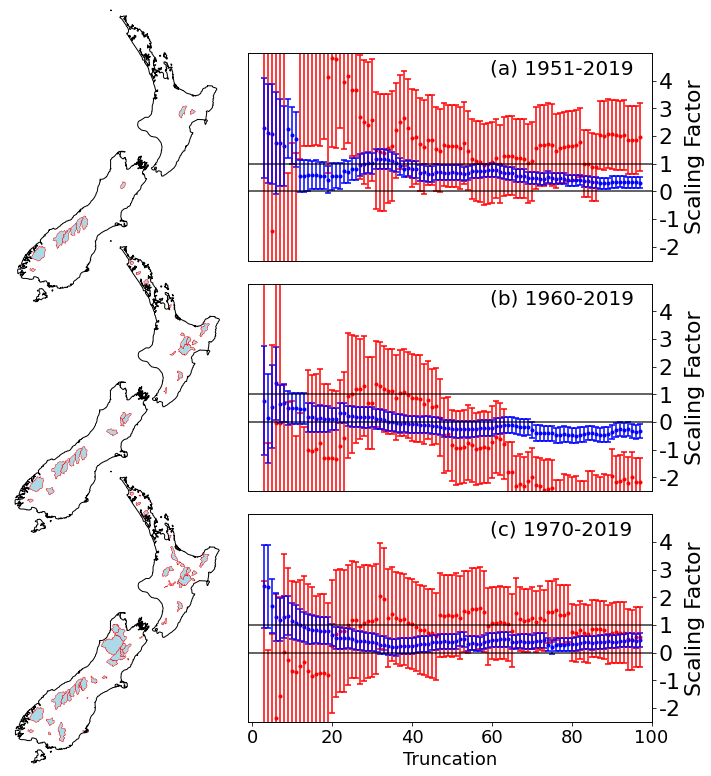

In [163]:
'''
GAUSSIAN RESULTS
'''

# Set-up figure
fig = plt.figure(figsize=(12,14))#, layout="constrained")
gs = fig.add_gridspec(15, 10)

# map axes
ax0 = fig.add_subplot(gs[0:5, 0:4],projection=ccrs.PlateCarree())
ax2 = fig.add_subplot(gs[5:10, 0:4],projection=ccrs.PlateCarree())
ax4 = fig.add_subplot(gs[10:15, 0:4],projection=ccrs.PlateCarree())

# OF axes
ax1 = fig.add_subplot(gs[1:4, 4:])
ax3 = fig.add_subplot(gs[6:9, 4:])
ax5 = fig.add_subplot(gs[11:14, 4:])

axs = [[ax0,ax1],[ax2,ax3],[ax4,ax5]]


end = 2019
trunc = np.array([i for i in range(3,98)])

labels = ['(a)','(b)','(c)']
for i,start in enumerate([1951,1960,1970]):
       
    ax = axs[i]
    
    # determine active sites
    sites = start_years[start_years<=start].dropna(axis=1).columns
    
    # plot active catchments
    catchments = catchment_data.loc[catchment_data['SITE'].isin(sites)]
    catchments['geometry'].plot(ax=ax[0],facecolor="lightblue", edgecolor='red',linewidth=.3)
    ax[0].coastlines()
    ax[0].set_extent([166,179, -47.5,-34])#, crs=noproj)
    ax[0].axis('off')
    
    plot_saved_result(ax[1],'winter',str(start),str(end),font,labels[i],'raw',True if i == 2 else False)

plt.subplots_adjust(left=None, right=None, top=None, bottom=None,wspace=-.05, hspace=-0.6)

In [161]:
def plot_saved_result(ax,season,start,end,font,label,processing,xlabel=False):
    
    if processing == 'gaussian':
        df = pd.read_csv('hydro_attribution/result_files/d4PDF_ROF_obs_'+season+'_'+start+'_'+end+'.csv')
    elif processing == 'raw':
        df = pd.read_csv('hydro_attribution/result_files/d4PDF_ROF_obs_raw_'+season+'_'+start+'_'+end+'.csv')

    ax.scatter(df['Truncation'],df['ant_best'],color='red',marker='.',label='ANT')
    ax.scatter(df['Truncation'],df['ant_upper'],color='red',marker='_')
    ax.scatter(df['Truncation'],df['ant_lower'],color='red',marker='_')
    ax.vlines(df['Truncation'],df['ant_lower'],df['ant_upper'],color='red')

    ax.scatter(df['Truncation'],df['nat_best'],color='blue',marker='.',label='NAT')
    ax.scatter(df['Truncation'],df['nat_upper'],color='blue',marker='_')
    ax.scatter(df['Truncation'],df['nat_lower'],color='blue',marker='_')
    ax.vlines(df['Truncation'],df['nat_lower'],df['nat_upper'],color='blue')

    ax.axhline(0,-0.5,1.5,c='black',alpha=0.8)
    ax.axhline(1,-0.5,1.5,c='black',alpha=0.8)

    twin_ax = ax.twinx()
    
    twin_ax.set_ylabel('Scaling Factor',fontdict=font)
    twin_ax.set_ylim(-2.5,5)
    twin_ax.set_yticks([-2,-1,0,1,2,3,4])
    twin_ax.set_yticklabels(['-2','-1','0','1','2','3','4'],fontdict=font)
    
    ax.set_ylim(-2.5,5)
    ax.set_yticks([])
    ax.set_yticklabels([],fontdict=font)
    
    font['size'] = 18
    
    ax.set_xlim(-1,100)
    if xlabel:
        ax.set_xticks([20*i for i in range(6)])
        ax.set_xticklabels([str(20*i) for i in range(6)],fontdict=font)
        ax.set_xlabel('Truncation',fontdict=font)

    else:
        ax.set_xticks([])
        ax.set_xticklabels('')

    font['size'] = 22
    
    ax.text(0.6,0.9,f'{label} {start}-{end}',transform=ax.transAxes,fontsize=20)
    
    plt.savefig(f'/home/queenle/hydro_attribution/dissertation/figures/streamflow_{processing}OF_time_windows.png',dpi=300)    

    